## Ash Kuinkel ~ cosc102 assignment 2 (Please run all cells in sequential order, or click "run all" at the top for a smoother experience)

### Brief Overview (Description of the program):
This program is crafted in a single section to accomplish our task as listed below;

Firstly, what is classification? Classification is a supervised machine learning task which relies on labelled data (i.e. input data labelled with what class they belong to), learns from this & uses this information learnt to be able to predict which new unseen items belong to which class. Our given task, follows a textbook application of modelling a classification workflow.

**Wine-Cultivar Classification** - We are required to apply a classifier algorithm of our liking to create a classifier which is able to classify the cultivar (specific type of grape grown in the vineyard) of wines from vineyards grown within the same region in Italy based upon 2 of the highest performing features ( selected using cross validation) out of the 13 available. A general gist/speculation on why only 2 features, will be provided further down below. The general set of steps that should be followed have been provided in the task description; loading dataset/partitioning, feature selection using cross validation, creating confusion matrix of classifiers performance on test set as well as calculating recall/precision/f1 scores, plotting & calculating ROC/AUC for each of the classes, demonstrating decision boundaries learnt by classifier w/ testing data points included in the form of a visual, i.e. scatter plot.


*I want to present my findings/what I have learnt for each of the steps (as this is how I worked through the assignment, step by step). So lets begin with what I first did, downloading and taking a look at the dataset.*

There were 2 things that stood out to me; a file named **wine.data** (which was of less importance) containing the 178 entries of all the different wines within the dataset & **wine.names** (of more importance) which specified what the dataset is actually containing. So from the wine.names I found that this dataset was derived from a chemical analysis, of wines in same region of Italy containing 3 different cultivars, which determined quantities of 13 chemical elements/parts found within each of the 3 types of wines. Also it lists that the author initially had approx. 30 variables instead of 13, but it appears that the author has lost the initial dataset. Anyways, the 13 features are listed here:

 	1) Alcohol
 	2) Malic acid
 	3) Ash
	4) Alcalinity of ash  
 	5) Magnesium
	6) Total phenols
 	7) Flavanoids
 	8) Nonflavanoid phenols
 	9) Proanthocyanins
	10)Color intensity
 	11)Hue
 	12)OD280/OD315 of diluted wines
 	13)Proline     

& we also see the number of instances of each class, i.e. (how many of the 178 entries belong to either class 1, 2 & 3):

    class 1 59
	class 2 71
	class 3 48 

This raises a subtle thought/question for me... It seems as if there are a little bit more instances of class 2, than class 1 or 3, so **should we automatically assume that the classifier will have some inclination to predict class 2 more often than the others (especially as we get closer to decision boundaries)?** But on second thought, I realise that the imbalance between the classes is very minimal. Either way, this is something to keep an eye on as we proceed through the later steps.

I also notice that there is a slight discrepancy here, on our ```wine.names``` our classes are labelled class 1,2,3... however the same wine dataset packaged with scikit learn labells the classes class 0,1,2. Through the notebook I will make use of the latter labelling, i.e. the 0,1,2.

### <u>Step 1 (Load dataset and partition dataset in the train/test sets):</u>

Lets first begin by importing the required libraries/modules that we will need to make use of throughout the program. ```sklearn.datasets``` enables us to fetch our wine cultivar dataset, ```sklearn.linear_model``` features linear models, including the SGDClassifier which will be the classifier algorithm we use for this task, ```sklearn.model_selection``` allows us to import our train_test_split method which makes it easy to parition our dataset (crucial for step 1) & the cross_val_predict method allowing for our training set to be split in folds & trains model on these folds and tests on unseen fold (all within training set, test set is not touched until very end), ```sklearn.metrics``` allows us to import methods for later steps, i.e. calculating confusion matrix, f1/recall/precision scores + roc/auc, ```sklearn.preprocessing``` imports label_binarize allowing for our multi-class label list to transform into a matrix (on one vs rest) so e.g. the matrix would have a row like [ 1 0 0 ] which would mean this is of class 0, [ 0 1 0 ] which is of class 1 etc.., ```matplotlib.pyplot``` allowing us to craft our visualisations, ```sklearn.pipeline``` & ```sklearn.preprocessing``` in which we are able to call our pipeline on the fly to help with standardisation & finally ```numpy``` for its multi-dimensional arrays & numerical operations.

In [20]:
from sklearn.datasets import load_wine
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split,cross_val_predict
from sklearn.metrics import confusion_matrix,f1_score,recall_score,precision_score,roc_curve,auc,ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

Now we must first load the wine dataset from scikit learn:

In [21]:
data = load_wine()

This is the other peice of the puzzle for step 1 & requires us to parition the data into training and test sets. We use the method we imported above the ```train_test_split``` which splits our data into random training/testing subsets. This is particularly important, to avoid overfitting to the training data, e.g say we don't split our data into training/testing sets, then we will come to find our model is almost perfect but if you then use the model on data it hasn't seen before then it will perform bad because it just memorised the training data to be able to perform well there. We can also get a false reporting of the performance of our model if there is data leakage, i.e. when some of the test set mixes up with the training set, making us think our model performs much better than it actually does. For an accurate reflection on the performance, in turn leading to higher confidence on the model, we must include the training/test data which can be generated using the train_test_split() method.

In [22]:
X, y = data["data"],data["target"]

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0) # note that our random state
# ensures reproducability of our results across different function calls (as acording to the scikit learn implementation docstrings)


This is all we must do for our first step. We can now move onto the second step which requires a bit more thinking.

### <u>Step 2 (Selecting 2 higher performing features based on cross-validation):</u>

This is the step which requires us to select the 2 highest performing features based upon cross validation carried out on the training set. 

I want to diverge from the main discussion here & first walk through my initial thought/workflow regarding this step before discussing my final implementation. So, at first this was my exact thought process (it is indeed a comment I wrote during the first draft of my task): 

```
# for choosing the features i.e. feature selection im thinking about either calculating like the scores for the model then 
# simply using like a for loop to compare and pull out two of the highest ones? Maybe that's what the task wants when it
# says Select the 2 most higher-performing features based upon cross-validation carried out on the training dataset.
# or im thinking maybe using RFE would be suitable which i picked up from this article:
# https://medium.com/@shradhdha.bhalodia/cross-validation-feature-selection-and-model-evaluation-with-scikit-learn-edc0e414c74e
# Even more interesting I came to this:
# https://www.geeksforgeeks.org/machine-learning/recursive-feature-elimination-with-cross-validation-in-scikit-learn/
```

I was hoping that there would maybe be a convinient method implementation already provided in SciKit learn to help us select the best performing features, rather than me having to write the for loops and compute e.g. the f1 scores to determine best features. So I came across this article on medium & reading this section, i.e.:

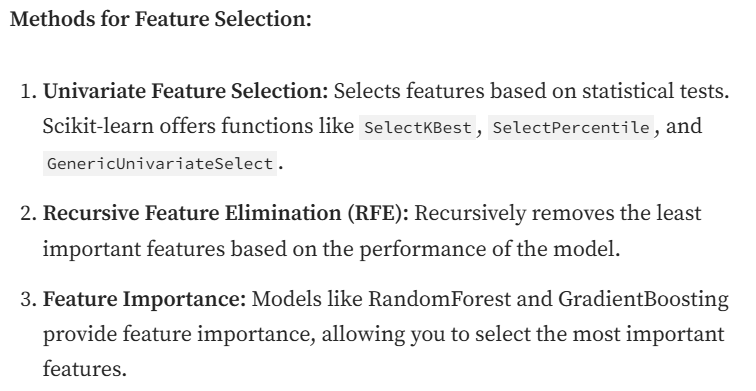

It seemed as if RFE (Recursive Feature Enlimination) kind of matched the behaviour we wanted our classifier program to follow & sure enough one browser search on *'RFE Scikit'* led me to exactly what I thought I needed. But reading the scikit documentation for RFE, in particular, the *'see also'* section, I saw something I thought was even better cut out for step 2 and did it exactly as outlined in our task description:

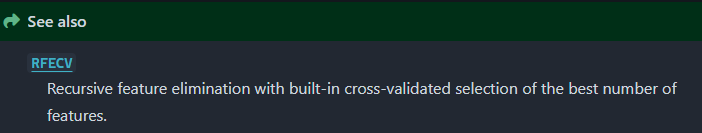

However, the *RFECV* posed a problem. We had a *min_features_to_select* param, but nothing to restrict the amount of features we want. I did indeed try setting *min_features_to_select* to 2 but it gave me 3 best features, so I thought we couldn't really make use of this & went back to looking at the *RFE*. I attempted to combine *RFE* with cross validation in such manner:

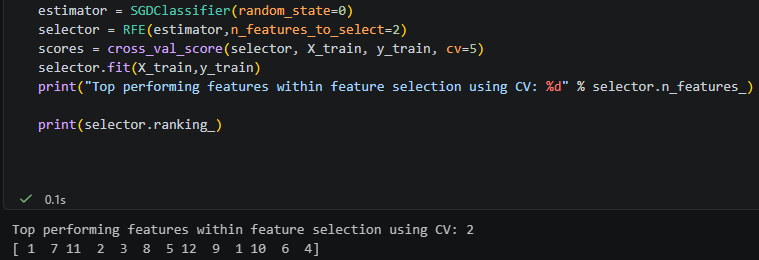

But I approached this in the other way I first thought of, i.e with the for loops (just to verify that I would get the same 2 features) and got back a completely different answer for the 2 best features. So I immediately knew that something was most likely wrong with the way I used *RFE* & the cv. Only by looking deeper into it, that I realised *RFE* is probably not the best for the task we want to acheive. 

Scikit learn's documentation page for *RFE* Specifically says ```Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), the goal of RFE....importance of each feature is obtained either through any specific attribute or callable```, so my interpretation of this is that *RFE* takes the 13 features which have had weights learnt by the SGDClassifier (the external estimator in this case), and because we're using SGDClassifier, a linear classifier, it uses (by default) the attribute ```coef_``` which would represent weight/coefficient matrix (according to https://scikit-learn.org/stable/glossary.html#term-coef_) for the features. So our RFE will use these weights/coefficients & just rank them & remove the worst one (so now 12 features remaining). It then trains the model again on the 12 features, learns some new weights/coefficeints removes the worst one etc. until we're left with 2 only.

But this was looking at features individually. I then realised, RFE/RFECV is not good enough because we want 2 most higher performing features, so we will literally have to pick out all possible combinations of 2 features, 13C2 = 13!/2!*(11)! so 78 total combinations and pick the one that scores the highest f1 scores etc....

So i ended up sticking with the for loop approach I initially thought of:

In [23]:
best_feature1 = 0
best_feature2 = 0
ttl_feature_amount = 13

def select_2_high_performing_features_based_on_cv(ttl_feature_amount : int) -> list[int]:
    '''
      Outputs the 2 highest performing features based on a total number of (ttl_feature_amount) features/cross validation & uses f1 scores as the performance metric.
    
      Args:
        ttl_feature_amount (int) : the total amount of features within the dataset.
    
      Returns:
        list[int] : [best_feature1,best_feature2] - the highest combination of features, with performance measured based on the f1 scores.
    '''
    best_mean_f1 = 0; # here we choose f1 as our performance metric, it serves as a good metric to use
    # considering it covers both accuracy & recall. 

    # The nested loop structure we have is going through all 169 possible pairings, but we intentionally skip the ones where feature 1 & feature 2 are the same so we have less than 169 iterations.
    # Also, the loops will consider like (2,3) & (3,2) different & will re-train the model on them, but given our input size is only like 13 features, and even up to some hundred features, I doubt that
    # it will have any significant effect on the speed/efficiency of our program. Hence, I have decided to leave this for now.
    for feature1 in range(ttl_feature_amount): 
        for feature2 in range(ttl_feature_amount):
            
            # we don't want to consider the combination where the 2 features are equal, so we 
            # can simply skip the iteration where they are indeed equal using the continue:
            if feature1 == feature2:
                continue
            
            curr_features_list = [feature1,feature2] # grab the two current features we're iterating over as we will use this to train the SGDClassifier model & compare it to other combinations of features...
            
            # With the Pipeline we are allowing a list of transformers which will help in preprocessing our data,
            # as listed here: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html#sklearn.pipeline.Pipeline
            # only within the pipeline do we define our standard scaler & our SGDClassifier.
            # The StandardScaler() ensures that we remove the mean & scale all features to have a variance of 1 (and hence std deviation of 1 as well because sqrt(1) = 1).
            # This is particularly important as our features may not exactly follow a symmetric/normal distribution & hence this could affect the best features output we are given by this function.
            # (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
            # There is more on this in the notebook md section just below this cell.
            sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))]) 
            
            sgd_clf.fit(X_train[:,curr_features_list],y_train) # calling the .fit() method to train our SGDClassifier on all rows but only of the 2 current features we are iterating over. 
            
            # will run 5 fold cv using our SGDClassifier & the 2 features to predict targets & returns cross validated estimates for every input data point
            # as according to (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html)
            y_pred = cross_val_predict(sgd_clf,X_train[:,curr_features_list],y_train,cv=5) 
            
            curr_mean_f1 = np.mean(f1_score(y_train,y_pred,average=None)) # calculates the f1 score for all of our classes based on the model we just trained using the two features, then takes the mean and 
            # compares it to how the other features do. The average None ensures that we are able to handle our multi-class data as only then does scikit return one score for each of the classes,
            # if we didn't have average=None param we'd get an error here, as seen in the cell below.
            
            if curr_mean_f1 > best_mean_f1: # in other words, if the current pair of features is the best we've seen so far update our features/best mean f1 to the current pair/f1 score
                best_mean_f1 = curr_mean_f1
                best_feature1 = feature1
                best_feature2 = feature2

    print("Best feature 1: %d " % (best_feature1+1) + "which is also labelled: %s" % data.feature_names[best_feature1]) # I print out best_feature1 + 1 because python starts lists at 0, but dataset i.e. (wine.names file) starts it at 1, so to be a bit more accurate.
    print("Best feature 2: %d " % (best_feature2+1) + "which is also labelled: %s" % data.feature_names[best_feature2]) # Same story for this one too.
    print(f"Best mean F1: {best_mean_f1}")
    
    return [best_feature1,best_feature2]
        

As the task description mentions; *built-in functions for creating train/test split & the CV select data points randomly...running workflow many times may result in different results.* So this is something we have to keep in consideration, but the program has indeed been constructed to select the 2 highest performing features.

The Pipeline is used so we can automate the preprocessing with StandardScaler, we could do it manually as well but then there is a greater chance of error.

I also first tried the current mean calculation this without the ```average=None parameter```, and it seems that if we do not pass in ```average=None``` then scikit just defaults it to ```average='binary'``` and this is a problem for us since we are training a multi-class classifier not just a binary classifier, so it will not be able to perform the mean calculation, hence why this parameter is important.

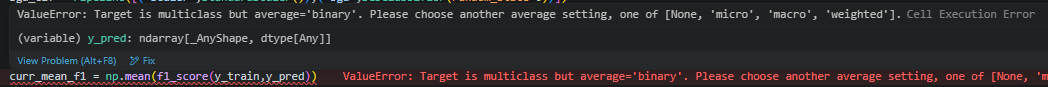

I think this step, i.e. step 2 required the most thought and time compared to the other steps within the task, but it is also one where I did learn a lot about feature selection in particular as well as the differences when handling a dataset with just 2 classes vs more than 2 classes.

So we have now fulfilled the requirements of the second step. Lets move onto the third:

### <u>Step 3 (Confusion matrix on classifier test set performance + Recall/Precision/F1 scores for classes):</u>

So for step 3, we must now first train the classifier on the 2 higher performing features based on our cv we found from our function above.

The implementation of this is quite simple, we are required to grab the two best features, train our model on them & see how they perform against the unseen test dataset. I think it is also important to note here once again that the test data must remain untouched until the very end. If we expose our model to the intended test data during training, then it will be tested on things it has already seen before, which does no good for calculating the accuracy,precision etc. of our model.

Best feature 1: 12 which is also labelled: od280/od315_of_diluted_wines
Best feature 2: 13 which is also labelled: proline
Best mean F1: 0.9028337562820322
Confusion Matrix:
 [[16  0  0]
 [ 1 18  2]
 [ 1  0  7]]


Text(0.5, 1.0, 'Confusion Matrix Visualisation on classifier performance on wine cultivar test set')

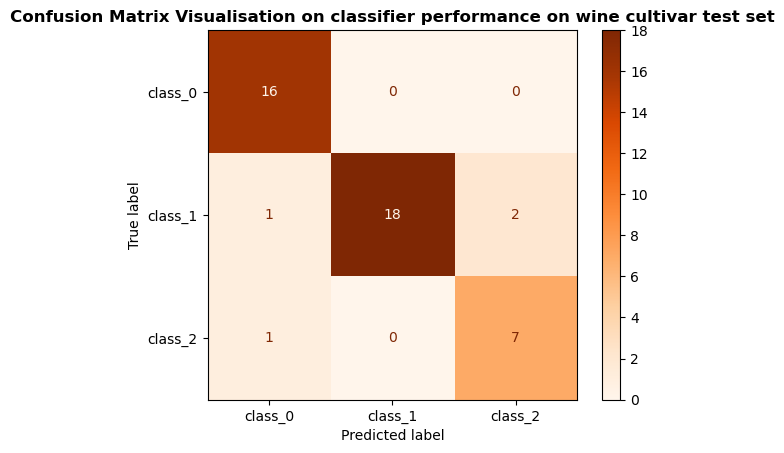

In [24]:
best_features_list = select_2_high_performing_features_based_on_cv(ttl_feature_amount) # storing the result of our function inside the var to use for later steps.

# once again, we use the pipeline like before here to standardise our training/test data for the SGDClassifier.
sgd_clf = Pipeline([("scaler",StandardScaler()),("sgd",SGDClassifier(random_state=0))])
sgd_clf.fit(X_train[:,best_features_list],y_train) # training model on the two higher performing features

y_pred = sgd_clf.predict(X_test[:,best_features_list]) # using the two features only from our test dataset, here is where our classifier is predicting what class every entry should belong to based on it's training data... truly, a very cool line ;) 

# the confusion_matrix() method lets us conviniently calculate our confusion matrix to evaluate the accuracy of our classifier... 
# (https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html):
conf_matrix = confusion_matrix(y_test,y_pred) 

print(f"Confusion Matrix:\n {conf_matrix}") # printing out the conf matrix to CLI

# These next sequence of steps are all taken to help us visualise the confusion matrix:
fig,ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(sgd_clf,X_test[:,best_features_list],y_test,display_labels=data.target_names,cmap=plt.cm.Oranges,ax=ax)
ax.set_title("Confusion Matrix Visualisation on classifier performance on wine cultivar test set",fontweight="bold")


So we first see that our function is printing out the 2 best identified features (because of the print statements in the function). The f1 score is used as a metric to determine how well our model did, since it is a harmonic mean of the precision and recall, the best mean f1 of our model was ~0.9 which is very good. So our function has gotten this best mean f1 score with the features ```od280/od315_of_diluted_wines``` & ```proline```. 

From the confusion matrix, we see that the model correctly identified all the class 0 elements. For class 1, it classified 18 correctly, however it classified 1 as class 0 and 2 as class 2. Finally, for class 2, it classified 7 correctly as class 2, but it classified 1 as class 0. Using this confusion matrix we can manually calculate the precision, recall, f1 scores, but scikit learn already has some methods we can use for this job.

In [25]:
recall = recall_score(y_test,y_pred,average=None)
precision = precision_score(y_test,y_pred,average=None)
f1 = f1_score(y_test,y_pred,average=None)

print(f"Recall Score : {recall}" )
print(f"Precision Score : {precision}" )  
print(f"F1 score: {f1}" ) 

Recall Score : [1.         0.85714286 0.875     ]
Precision Score : [0.88888889 1.         0.77777778]
F1 score: [0.94117647 0.92307692 0.82352941]


So how can we interpret these results now? Well, we know, in simple words recall is a measure of how many intended targets did our model find? To be more precise it is a measure of ( true positives/ (true positives) + (false negatives)). Recall is very important for cases where we want to make sure we are not missing out on any targets and having a false negative will have more consequences as compared to false positives. On the other hand, precision is a measure of all the positives model was able to predict, how many were actually positive. Once again, to be more precise it is a measure of (true positives/(true positives + false positives)) and precision is very important for cases where we want to avoid having any false positives i.e. when we want to make sure what's in our class 1 actually belongs to class 1. We do also know the trade-off between recall & precision, i.e. as recall increases, precision decreases & vice versa, this inverse relationship is reflected through our confusion matrix, recall/precision scores, e.g. when recall score is 1 for class 0, the precision score is 0.89 (2.d.p) etc. We see our f1 scores for class 0 & class 1 are excellent (90+), and our f1 score for class 2 is good (80+).

I also want to discuss an important point here. While the marking rubric does say ```Have you generated general-purpose/reusable functions?``` I have intentionally not generated a function for this step. I argue that there is no need for function here. We could indeed create one, but who knows, maybe next time you want to use the KNN algorithm, or maybe you want to change the colour of your confusion matrix, either way the core logic in this step only spans approx. ~4 lines (that is definetly not to say the amount of lines you have in your code dictates if a function is necessary all the time, it does not) and is not something that will benefit much from having a reusable function. In fact, i argue that attempting to create a function here will only strip away the simplicity/flexibility of the program.

### <u>Step 4 (ROC Values for classes & Auc calculations):</u>

Lets quickly dive into what the ROC & AUC is/represents. The ROC curve is another tool we used to see how well our classification model performs, it does this by plotting the true positive rate against the false positive rate, and the important thing to note that it does this across the possible decision thresholds. So instead of us manually calculating the recall, etc. for certain decision thresholds, the ROC curve allows for a quick & efficient visualisation. The AUC represents the area under the ROC curve ranging from 0 to 1, where 1 represents better performance, it just measures how well is our classifier differentiates between two classes.

Also, note that because these ROC/AUC are typically done with binary classifiers, and we are dealing with a multi-class classifier in this program, there are some certain steps we need to take to ensure we are able to calculate the ROC curves/AUC. E.g, we need to use the label_binarize() which, as the name suggests, converts our classes which are our target labels into a binary format. An important thing to note is that the label_binarize() method does this using OvR method (as listed here: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.label_binarize.html). This begs the question, what is OvR & OvO? Simply put, these are just ways a multi-class classifier adapts to using a binary classifier algorithm (remember ROC/AUC expect binary). OvR (one vs rest) which is being used, in our case emphasises the need to train 3 binary classifiers, one for each of our 3 classes, i.e. class 0, class 1, class 2 & when we are attempting to classify which class a wine belongs to we would run each of the 3 binary classifiers, see which classifier gives us the highest decision score (which is just a measure of how far an individual point is away from the decision boundary & in turn, how confident the model is that this individual point belongs to this class) & use this classifier. On the other hand, the OvO (one vs one) would just train a binary classifier for all distinct pair combinations of our wine classes. This means one for class 0 & 1, one for class 1 & 2, class 0&2, so in our case there is only 3 times the binary classifier is being trained, but we can work out how many times our classifier is being trained for other datasets using the formula:

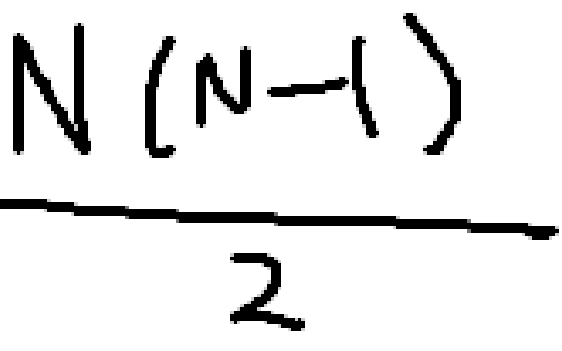



where of course, N represents the number of classes.

{0: 0.997844827586207, 1: 0.9781746031746031, 2: 0.9527027027027026}


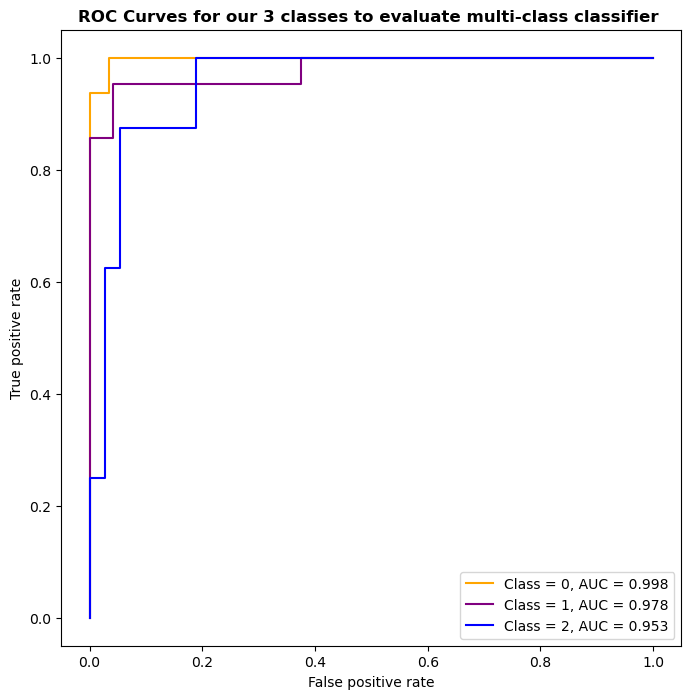

In [26]:
y_scores = sgd_clf.decision_function(X_test[:,best_features_list]) # for the test set we tested our classifier on, perform calculations on how far every point is from the decision boundary (which is a measure of how confident is the model that the point belongs to the class
# it's predicted to belong in) & return the raw confidence scores.

y_test_bin = label_binarize(y_test,classes=[0,1,2]) # ROC/AUC expect binary format, so convert our outputs from each of the 3 classes into a binary format using the OvR strategy.

# initialise dictonaries to hold the values for our respective variables we will plot/use.
false_positive_rate = dict() 
true_positive_rate = dict()
roc_auc = dict()

fig,ax = plt.subplots(figsize=(8,8))
colours_for_curves = ['orange','purple','blue']

for i in range(3):
    false_positive_rate[i],true_positive_rate[i],_ = roc_curve(y_test_bin[:,i],y_scores[:,i]) # for every class i.e. 0,1,2 we make use of the binary format from y_test_bin/confidence scores from y_scores to plot the ROC curve across different decision boundaries/thresholds. 
    roc_auc[i] = auc(false_positive_rate[i],true_positive_rate[i]) # for every class just make use of the fpr/tpr in calculating the auc for each of the 3 classes.

    # plot the ROC curves to a plot which we can visualise:
    ax.plot(false_positive_rate[i],true_positive_rate[i],color=colours_for_curves[i],label=(f"Class = {i}, AUC = {roc_auc[i]:.3f}"))

plt.legend(loc=4) # matplotlib has codes for the loc, 4 means lower right
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title("ROC Curves for our 3 classes to evaluate multi-class classifier ",fontweight="bold")

print(roc_auc)

Usually, we think of a curve as a smooth line which has a bend and is continous. However, our ROC curves are actually more of a staircase looking shape with sharp 90 degree turns. This is due to the dataset being small & hence the training set also being even smaller.

However, lets interpret these results for the AUC. Class 0 has the highest AUC score at 0.998. This means that our if we give our model data which is a mix of ones belonging to class 0 & some belonging to other classes i.e. class 1, or 2, our model will assign a confidence score to each of the data points & then rank them from highest to lowest score. Because for class 0, the auc is 0.998 allows us to say that our model is able to rank the individual datapoints 99.8% correcttly, and there may just be one little misclassified point out of the entire test set. Similarly, this applies for class 1 and 2, e.g. for class 1 we see the AUC = 0.978 and hence we say our model is able to rank inidivudal datapoints 97.8% correctly & same for class 2. An AUC of 1 represents a flawless model & an AUC of 0.5 represents a model which essientially randomly ranks our datapoints, and less than 0.5 means it is worse than the random ranking. So overall, we see our multi-class classifier performs exceptionally well for all the 3 classes.

### <u>Step 5 (Visualisation including decision boundary):</u>

We must now complete the final step of this program, which requires us to visualise the decision boundaries which have been learnt by our classifier. Well one thing to bring to light is that our classifier is not able to just draw any shapes, lines etc. it's job is to classify data, more specifically predict the class a certain point belongs to. So as a rough guide, we must establish a min & max for the x & y axis, and between the min/max go up by very small increments, e.g. 0.01, these numbers will be fed to our classifier as if they are real data points & the classifier will predict either class 0, 1 or 2. If we're going up by 0.01 then we should have thousands of predictions. These predictions will be coloured in to visually represent the different classes, and where the colours meet is known as the decision boundary. Then we can plot these dots which looks like solid block of colour to the human eye.

I have also decided to include another function here as the task does require some reuseable functions. Although I wouldn't necessarily enforce the need for a function here, it has been included as it is possible that this peice of code within the function is used again and would benefit from having this decision boundary visualisation process shortened to a function call.

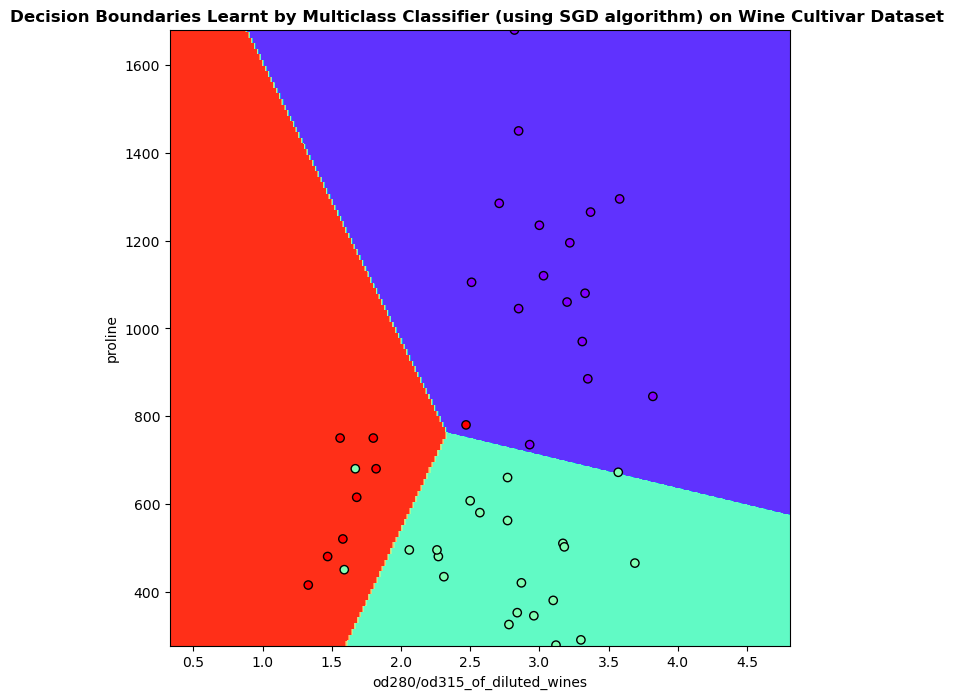

In [27]:
# This is our test dataset but with only the points for our two best features, so e.g.
# instead of having the dataset for all 13 features, we grab only 2.
X_test_selected = X_test[:,best_features_list]

def plot_decision_boundaries_for_best_2_features(classifier_model:SGDClassifier,best_2_features_list:list[int],testing_data_points:np.ndarray,X_test:np.ndarray,y_test:np.ndarray,step:float=0.01) -> None:
    '''
    Plots the decision boundaries learnt by classifier model using the best 2 features, with the test data plotted accross decision regions.
    
    Args:
      classifier_model (SGDClassifier): The model which will predict which class all the points belong to in the decision boundary visualisation.
      best_2_features_list (list[int]): The list containing indices of the best two features from the feature set, used to help plot the decision boundary.
      testing_data_points (np.ndarray): The testing data points of only the two best features, used to help plot the testing data within the decision boundary visualisation.
      X_test (np.ndarray): The entire test data set for all of the features.
      y_test (np.ndarray): The actual class labels for our test data, e.g. class 0, 1 or 2.
      step (float): The interval we will use when creating the visualisation, represents the space between the dots in the grid.
    '''
    # using best feature 1 and best feature 2 variables don't work here... as I they're within local scope of my function I defined in step 2
    # so trying to use them here would set their values to 0... so instead we do:
    feature_x_index = best_2_features_list[0]
    feature_y_index = best_2_features_list[1]

    # In this step, we are essientially defining the boundaries of our graph which we will create.
    # e.g. for x_min we grab one of the best features, find the minimum value of this column throughout the 
    # dataset, and takeaway 1 to leave a little room...
    x_min, x_max = X_test[:,feature_x_index].min() - 1, X_test[:,feature_x_index].max() + 1
    y_min, y_max = X_test[:,feature_y_index].min() - 1, X_test[:,feature_y_index].max() + 1

    xx,yy = np.meshgrid(np.arange(x_min,x_max,step),np.arange(y_min,y_max,step)) # note that our model is good at classifying points but it has no way to draw a grid.
    # so we combine np.arrange() which between our min x and max x value & min y/max y creates points in 0.02 increments with np.meshgrid() which helps in duplicating
    # the lists, converting them to same size matrices and then gives the model thousands of different coordinates to classify as if they were real wine data with 
    # m amount of feature1 & n amount of feature2, and for every coordinate, our model will return a prediction of which class that coordinate belongs to.
    # For all the coordinates that were classified as class 0 they get one colour, for coordinates classified as class 1 they get one colour etc. Where the colours meet
    # is also known as the decision boundary. 

    grid_predictions = classifier_model.predict(np.c_[xx.ravel(),yy.ravel()]) # this is the step where we are giving the model the coordinates for it to predict class 0, 1 or 2.

    # putting the result, which is just the predictions of class 0,1,2 in a list because of our .ravel() previously, back into a 2d format which matplotlib is able to plot with:
    grid_predictions = grid_predictions.reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(8,8)) 

    ax.contourf(xx,yy,grid_predictions,cmap="rainbow") # colour the class predictions our model made in grid_predictions with colours so we are able to visually see the classes.

    ax.scatter(testing_data_points[:,0],testing_data_points[:,1],c=y_test,cmap="rainbow",edgecolor="black") # plot all our testing data points accross the grid in a scatter plot format.

    plt.xlabel(data.feature_names[feature_x_index])
    plt.ylabel(data.feature_names[feature_y_index])
    plt.title("Decision Boundaries Learnt by Multiclass Classifier (using SGD algorithm) on Wine Cultivar Dataset ",fontweight="bold")

    plt.show()
    
plot_decision_boundaries_for_best_2_features(sgd_clf,best_features_list,X_test_selected,X_test,y_test,0.02)

I first want to come back to the thought I had at the beginning; **should we automatically assume that the classifier will have some inclination to predict class 2 more often than the others (especially as we get closer to decision boundaries)?** It seems as if the answer to this is no, most likely due to the small level of imbalance within the dataset. Most importantly, we also now learn that the part about *'getting close to decision boundaries'* does not really mean the model will/be more likely to classify a point as class 2 because a point closer to the decision boundary just means that the model is less confident in its classification of that specific point. 

There are some interesting things to note here. The plot in step 5 is indeed a direct translation of our confusion matrix from step 3, which is to be expected. We also only picked two features we have a nice 2d visual to look at, as we can't really visualise 13 dimensions. Whilst this may sound good, it also means that we are only ever letting our classifier model predict which class the points belong to based upon the 2 features, whereas including all the other features could've helped classify some of the points which are misclassified. This is something which can indeed be improved. I am planning to come back to and refactor to include the dimensionality reduction techniques after we learn about it in week 12, and see how much of a difference it makes to our classification model. 

Finally, from the visualisation in step 5, it can be seen that our decision boundaries are linear, i.e. like straight lines. I didn't try to reattempt the assingment using another algorithm, but I was intrigued at what a KNN algorithm visualisation for a multi-class classifier would look like, so i searched it up online, and came to find, it looks a little different:

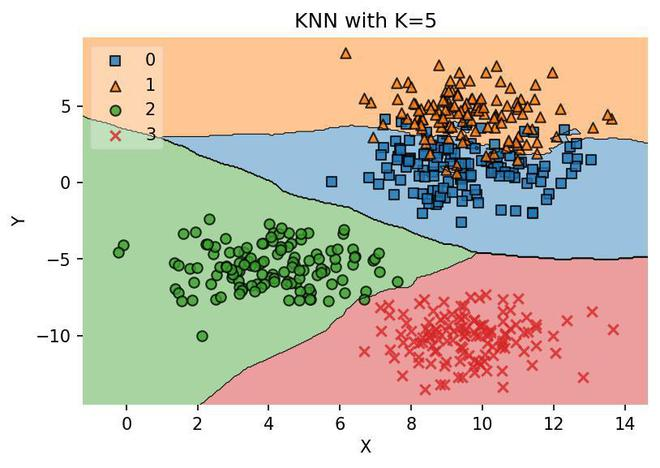

(https://www.geeksforgeeks.org/machine-learning/how-to-visualize-knn-in-python/)

It seems as if the decision boundaries for the KNN algorithm are non-linear. But KNN is also a non-linear algorithm. So this leads me to believe that whether the decision boundaries are linear or non-linear is dependant on the algorithm we choose to implement.



Overall, this was a fun assignment which introduced me to classification (binary/multi-class). I particularly enjoyed finding out more about feature selection in step 2, and the process required to create the visualisation in step 5. I also want to extend to my thoughts from step 2, in which I attempted to use RFE, and found out this wasn't the most applicable method for our scenario in this assignment. I immediately moved onto using the for loop which I had first proposed, however I didn't try the univariate feature selection, which selects features based on statistical tests, in particular the selectKBest method which the medium article proposes. I am now wondering if that could've been applicable to our case. I am certain that in a real world setting deploying a classification model would require much more time and thought as well as complexity, however the basics/core implementation ideas will remain the same. By completing this assignment, I now feel like I have a better understanding of classifiers. I now clearly see how this can be used to help me when building some of my own projects, e.g. a binary classifier to detect if a process should be classified as malicious or not at the operating system level by analysing the way it runs/its features to send warnings and keep a close eye on that process in different environment.